# 01. PyTorch 워크플로우 기본 사항


- Pytorch Workflow
1. 데이터 준비 <br>
2. 모델구축 <br>
    -데이터에서 패턴을 학습하는 모델 생성, 손실 함수와 최적화 도구 선택, 학습 루프 구축<br>
3. 모델을 데이터에 맞추기(학습)<br>
    -모델이 데이터에서 패턴을 찾아내도록 훈련<br>
4. 예측 및 모델 평가(추론)<br>
    -모델이 데이터에서 패턴 찾았으므로 그 결과를 실제 데이터와 비교(테스트)<br>
5. 모델 저장 및 불러오기<br>
    -모델을 다른 곳에서 사용하거나 나중에 다시 활용할 수 있도록 함<br>
6. 모든 것들을 종합<br>
    -위 모든 내용들을 종합<br>


*torch.nn : nn은 neural network의 약자, 이 패키지는 PyTorch에서 신경망을 만들기 위한 기본 구성 요소들을 담고 있음


In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__  #check pytorch version

'2.9.1+cu126'

# 1) 데이터 (준비 및 로딩)


- 머신러닝은 두 부분으로 이루어짐
1. 어떤 데이터든 숫자로 표현
2. 표현 방식을 최대한 잘 학습 할 수 있는 모델 선택/구축
- 데이터를 직선 형태로 만들기 <br>
-> 선형 회귀를 사용해 알려진 매개변수(모델이 학습할 수 있는 요소)를 가진 데이터 생성 -> pytorch 사용해 경사하강법으로 이 매개변수를 추정하는 모델 구축

In [3]:
# 알려진 매개변수 생성
weight = 0.7
bias = 0.3

#데이터 생성
start = 0
end = 1
step = 0.02
X = torch.arange(start, end , step).unsqueeze(dim=1)  #unsqueeze로 차원 추가
y= weight*X + bias

X[:10], y[:10] #앞에서부터  10개 데이터 확인

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

# 데이터를 훈련 세트와 테스트 세트로 분할

- 훈련 세트 : 이 모델은 이러한 데이터(예: 학기 중에 공부하는 교재)를 통해 학습 <br>
총 데이터 양- 약 60~80%, 매번 사용
- 검증 세트 : 이 모델은 이러한 데이터(기말고사 전에 치르는 모의고사처럼)를 기반으로 조정됨 <br>
총 데이터 양- 약 10~20%, 매번 사용되는 것은 아니지만 자주 사용됨
- 테스트 세트 : 이 모델은 학습한 내용을 검증하기 위해 해당 데이터를 기반으로 평가됨 <br>
총 데이터 양- 약 10~20%, 매번 사용

-X와 y를 분할함으로써 위의 세트들 생성 가능

*제 데이터를 다룰 때는 이 단계를 프로젝트 시작 단계에서 수행 <br>
*테스트 세트는 항상 다른 모든 데이터와 분리해야 함 <br>
*모델이 훈련 데이터로 학습한 다음 테스트 데이터로 평가하여 이전에 보지 못한 예제에 얼마나 잘 일반화되는지 파악하는 것이 목표<br>


In [4]:
#create train/test split
train_split = int(0.8*len(X)) # 데이터의 80%가 훈련 세트에 이용됨, 20%는 테스트
X_train, y_train = X[:train_split], y[:train_split]  
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

--> 훈련을 위한 샘플들(X_train & y_train) 40개와 테스트를 위한 샘플들(X_test & y_test) 10개를 얻음 <br>
-우리가 만든 모델은 X_train & y_train 사이의 관계를 학습하려고 할 것 <br>
-우리는 X_test & y_test 를 이용해 그 모델이 학습한 것을 평가 할 것임 <br>

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    
    """
    훈련 데이터, 테스트 데이터 를 그래프로 그린 후 예측값을 비교
    """
    plt.figure(figsize=(10,7))
    
    # 훈련 데이터를 파란색 그래프로 그림
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    #테스트 데이터를 초록색 그래프로 그림
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    
    if predictions is not None:
        #예측값을 빨간색 그래프로 그림 (예측은 테스트 데이터 기반으로 수행됨)
         plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
         
    
     # 범례 표시
    plt.legend(prop={"size": 14})


*import matplotlib.pyplot as plt 가 생략된 것 <br>
**mayplotlib : 그래프 그리는 도구 상자

# 2) 모델 구축

- 파란색 점을 이용해 초록색 점을 예측하는 모델 <- 표준 선형 회귀 모델




In [6]:
import torch
import torch.nn as nn
#1. class 정의 - 선형 회귀 모델 class 생성
class LinearRegressionModel(nn.Module) : # pytorch의 거의 모든 것들이 nn.Module. 뉴럴 네트워크 레고 블록이라고 생각하기
    def __init__(self): # 생성자 __init__
        super().__init__() #nn.Module의 초기화 작업 수행
        self.weights = nn.Parameter(torch.randn(1, #가중치 정의  #평균 0, 분산 1인 정규분포 난수 1개. 초기 가중치를 랜덤으로 설정. #nn.Parameter(...) : 이 텐서를 모델이 학습해야 할 파라미터라고 pytorch에게 알려줌
                                                dtype=torch.float), #자료형32. pytorch 기본 실수타입
                                    requires_grad=True) # <- can we update this value with gradient descent?  #이 값에 대해 미분을 계산
        self.bias = nn.Parameter(torch.randn(1, 
                                             dtype=torch.float),# 편향 정의 # 랜덤 편향값으로 시작(이 값은 모델이 학습하면서 조정됨). 직선의 y절편에 해당.
                                 requires_grad=True)            # <- can we update this value with gradient descent?
    def forward(self, x:torch.Tensor) -> torch.Tensor: # x는 입력값 ex. 학습/테스트용 특징값들
        return self.weights * x + self.bias #선형 회귀 공식 (y = m*x + b)
# nn.Paramemter들이 무작위로 초기화 되기 때문에 수동 시드 값 설정
torch.manual_seed(42) #난수 생성을 위한 시드를 42로 고정

# 모델의 인스턴스 생성 (이 모델은 nn.Parameter을 포함하는 nn.Module의 하위 클래스)
model_0 =  LinearRegressionModel()

# 만든 nn.Module 하위 클래스 안에 있는 nn.Parameter들을 확인
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


# PyTorch 모델 구축 필수 요소
- 거의 모든 종류의 신경망을 만들 수 있는  pytorch 네가지 핵심 모듈 : torch.nn, torch.optim, torch.utils.data.Dataset. torch.utils.data.DataLoader
1. torch.nn <br>
: 계산 그래프(정해신 순서대로 수행되는 연산들의 묶음)를 구성하는 모든 구성 요소들을 포함하고 있음
2. torch.nn.Parameter <br>
: nn.Module에서 사용할 텐서를 관리. requires_grad=True로 설정된 경우 모델 학습에 필요한 기울기(gradient)를 자동으로 계산해주는데 이 기능을 autograd라 함.
3. torch.nn.Module <br>
: nn.Module은 모든 신경망 구성 요소의 부모 클래스, PyTorch에서 신경망 모델을 만들 때 반드시 이를 상속 받아야함. forward()메서드의 구현 필수.
4. torch.optim <br>
: 모델 학습에 사용되는 여러 최적화 알고리즘을 제공하며, 이 알고리즘들은 nn.Parameter로 저장된 파라미터들이 손실을 줄이기 위해 어떤 방향과 크기로 바뀌어야 하는지 결정.
5. def forward() <br>
: nn.Module을 상속한 모든 클래스는 forward() 메서드를 반드시 구현해야 하며, 이 메서드는 입력 데이터가 들어왔을 때 모델이 어떤 연산을 수행할지를 결정.

- torch.nn : PyTorch 신경망의 거의 모든 것이 옴
- nn.Module : 더 큰 구성 요소들(레이더들)을 포함
- nn.Parameter : 가중치와 편향 같은 작은 파라미터들을 담고 있음. 이들을 모아 nn.Module 만듬
- foward():  nn.Module 안에서 큰 블록들이 입력값(데이터가 들어있는 텐서)에 대해 어떤 계산을 수행할지 알려줌
- torch.optim : nn.Parameter 안의 파라미터들이 입력 데이터를 더 잘 표현하도록 향상시키는 방법들을 담고있음

# PyTorch 모델의 내용 확인
-만든 클래스로 모델 인스턴스 생성하고 .parameters()를 사용해 해당 매개변수 확인해보기


In [7]:
# nn.Paramemter들이 무작위로 초기화 되기 때문에 수동 시드 값 설정
torch.manual_seed(42) #난수 생성을 위한 시드를 42로 고정

# 모델의 인스턴스 생성 (이 모델은 nn.Parameter을 포함하는 nn.Module의 하위 클래스)
model_0 =  LinearRegressionModel()

# 만든 nn.Module 하위 클래스 안에 있는 nn.Parameter들을 확인
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
model_0.state_dict() #모델의 상태(모델에 포함된 내용).  

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

- model_0.state_dict()에서 가중치와 편향이 임의의 부동 소수점 (실수) 텐서로 나옴 <br>
-> torch.rand()을 이용해 초기화했기 때문

-  모델은 처음에 무작위 파라미터에서 시작 -> 학습을 통해 데이터에 가장 잘 맞는 파라미터로 점점 업데이트되도록 만듬 (우리가 직선 데이터를 만들 때 우리가 설정해두었던 weight와 bias 값에 가까워지도록)
-모델이 랜덤한 값에서 시작하기 때문에 현재 상태에서는 예측 성능이 좋지 않을 것

Q. 두 개의 셀 위에 있는 torch.manual_seed() 값을 바꿔보고,
weights와 bias 값에 어떤 변화가 생기는지 확인해보기

# torch.inference_mode() 이용해 예측하기

-이를 확인하기 위해 테스트 데이터인 X_test를 모델에 넣어서 모델이 y_test를 얼마나 잘 예측하는지 확인 가능 <br>
-데이터를 모델에 전달 -> 그 데이터는 모델의 forward( ) 메서드 통과하면서 우리가 정의해 둔 계산식에 따라 결과 만들어냄

*학습 안 하고 예측만 함

In [9]:
# 모델로 예측하기
with torch.inference_mode( ): 
    y_preds =model_0(X_test)  #X_test를 모델에 넣어 예측값 y_preds 만듬


- 우리가 예측을 만들 때 torch.inference_mode(   )를 컨덱스트 매니저로 사용함 <br>
-> torch.inference_mode(  ): 모델로 예측할 때 사용하는 기능 <br>
- torch.inference_mode()는 여러가지 기능 꺼버림 <br>
-그 중 하나가 gradient(기울기) 추적
-기울기 계산을 학습할 때는 필요하지만 에측할 땐 필요 없 -> 이를 꺼서 forward 연산(모델의 forward()를 통과하는 계산)을 더 빠르게 만들어줌


In [10]:
#예측 체크
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")


Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


-직선(선형) 관계 데이터 사용하고 있음 -> X 값 하나가 y값 하나에 대응 <br>
-머신러닝 모델은 훨씬 더 유연해서 X값 100개가 y값 1,2, 10개 등으로 매핑 가능


In [11]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

# 3) 모델 학습 (Train model)

- 지금 모델은 랜덤 값으로 계산해 예측 중(찍고 있는 상태)
-모델 내부의 파라미터(=패턴), 즉 weight(기울기)와 bias(절편) 값을 현재 랜덤 값에서 데이터를 더 잘 설명하는 값으로 업데이트 해야 함
- 이 값들은 nn.Parameter()와 torch.randn()으로 처음에 무작위로 설정했던 것들
-사실 우리는 이 직선의 진짜 값이weight = 0.7, bias = 0.3 인 걸 알고 있어서 그냥 코드에 직접 써버릴 수도 있 
    but 현실에선 대부분 정답 파라미터 모름
- 이 모델이 스스로 데이터를 보고 가장 잘 맞는 weight와 bias를 찾아내도록 하는 것 --> 머신러닝

# Pytorch에서 loss function(손실 함수)와 optimizer(최적화 도구) 생성
- loss function(손실 함수), optimizer(최적화 도구) -> 모델이 스스로 파라미터(가중치, 편향) 업데이트하게 하기 위해 필요<br>

- loss function(손실 함수): 모델의 예측(ex.y_preds)이 실제 정답(예. y_test)과 얼마나 다른지 흑정하는 함수 <br>
-값이 낮을수록 예측이 더 정확하다는 뜻 <br>
-Pytorch에 torch.nn 안에 이미 다양한 손실 함수들이 내장되어있음<br>
-회귀(숫자 예측) 문제-> 평균 절대 오차(MAE) 사용 torch.nn.L1Loss <br>
-이진 분류(0 또는 1로 나누는 문제)-> Binary Cross Entropy 사용 orch.nn.BCELoss()

- optimizer(최적화 도구) : 모델이 손실을 최소화하기 위해 내부 매개변수를 업데이트하는 방법 알려줌 <br>
-torch.optim에서 사용 가능 <br>
-ex. SGD (torch.optim.SGD()), Adam (torch.optim.Adam()) <br>

- 모델 개선을 위한 손실 함수 & optimizer 만들기 <br>
-어떤 문제를 푸느냐에 따라 사용할 손실 함수 & optimizer 달라짐 <br>
-일반적으로 성능이 좋은 값들 : SGD(확률적 경사 하강법), Adam 옵티마이저 <br>
-회귀 문제(숫자 예측)- MAE(평균 절대 오차) 손실 함수, 분류 문제(이것이냐 저것이냐 예측)- Binary Cross Entropy 손실 함수 사용 <br>

- 우리는 숫자 예측하는 문제기 때문에 Pytorch의 torch.nnL1Loss에 들어있는 MAE(평륜 절대 오차)를 손실 함수로 사용할 것



평균 절대 오차(MAE, PyTorch에서는 torch.nn.L1Loss) : 두 값(예측값과 정답) 사이의 절대적인 차이 측정한 후 모든 예제에 대해 그 값들의 평균 계산한 값 <br>
*MAE = Mean Absolute Error
- 우리가 사용할 것 : SGD, torch.optim.SGD(params, lr) <br>
1. params : 최적화하고 싶은 대상 모델의 파라미터들 <br>
ex. 우리가 앞에서 랜덤으로 설정했던 weight와 bias 값들 <br>
2. lr : optimizer가 파라미터를 얼마나 크게 업데이트할지 나타내는 학습률 (learning rate) <br>
-값이 클수록 optimizer는 더 큰 변화량으로 업데이트 시도함 <br>
 (이 값이 너무 크면 업데이트가 과도해 optimaizer가 제대로 작동하지 않을 수 있음) <br>
-값이 작을수록 optimizer는 더 작은 변화량으로 업데이트 시도 <br>
(이 값이 너무 작으면 최적의 값에 도달하는데 시간이 오래걸릴 수 있음) <br>

- 학습률은 하이퍼파라미터로 간주됨 <br>
-머신러닝 엔지니어가 직접 설정하기 때문<br>
-학습률의 일반적인 시작 값 - 0.01, 0.001, 0.0001 등<br>
-이 값들은 학습 도중에 조정될 수도 있음 (학습률 스케줄링)<br>

*hyperparameter : 머신러닝 모델 학습 전에 사람이 직접 설정하는 값


In [12]:
#손실 함수 생성
loss_fn = nn.L1Loss() # MAE loss = L1Loss

#  optimaizer 생성
optimizer = torch.optim.SGD(
    params= model_0.parameters(), #최적화할 대상 모델의 파라미터들 (즉, weight와 bias)
    lr=0.01 #학습률 (= 옵티마이저가 매 단계마다 파라미터를 얼마나 바꿀지)
)

#예측이 얼마나 틀렸는지 MAE로 재고, 그 오차를 줄이기 위해 weight와 bias를 SGD 방식으로 0.01씩 조정


# PyTorch에서 최적화 루프 생성하기

- Training loop (훈련 루프) :  모델이 학습 데이터(training data)를 보면서 입력값(특성, features)과 정답값(레이블, lables) 사이의 관계를 배우는 과정
- Testing loop (테스트 루프) : 테스트 데이터(testing data) 사용해서 모델이 훈련 데이터에서 배운 패턴이 얼마나 잘 작동하는지 평가 하는 과정
    -모델이 훈련 중에는 테스트 데이터 절대 보지 않음
- 이 과정을 "루프"라고 부르는 이유- 모델이 각 데이터 샘플을 하나씩 반복해서 (loop through) 보기 때문 <br>
    -즉, 각 데이터셋의 모든 샘플을 순서대로 하나하나 처리한다는 뜻
    

# Pytorch 학습 루프
1. Forward pass(순전파) : 모델이 모든 학습 데이터를 한 번 통과시키면서 forward() 연산 수행 <br>
-model(x_train)
2. 손실 계산 (Calculate the loss) : 모델의 예측값과 실제 정답을 비교해 얼마나 틀렸는지 계산 <br>
-loss = loss_fn(y_pred, y_train)
3. 기울기 초기화 (Zero gradients) : optimizer에 저장된 이전 기울기들을 0으로 초기화(기울기는 기본적으로 누적되기 때문) <br>
-optimizer.zero_grad()
4. 역전파(Backpropagation) : 손실(loss)을 기준으로 각 파라미터가 얼마나 영향을 줬는지 계산 <br>
-loss backward()
5. 파라미터 업데이트(Optimizer step) :  계산된 기울기를 사용해 모델 파라미터를 조금식 수정(경사하강법) <br>
-optimizer.step

- pytorch 절대규칙<br>
1)역전파(loss.backwward())를 수행하기 전에, 손실값(loss = ...)을 계산 <br>
--> 얼마나 틀렸는지 먼저 계산하고 왜 틀렸는지 역전파로 분석<br>
2)각 모델 파라미터에 대한 손실 기울기를 계산하기 전에, 기울기들을 0으로 초기화해야 함(optimizer.zero_grad())<br>
--> 얼마나 틀렸는지 먼저 계산하고 왜 틀렸는지 역전파로 분석<br>
3)손실에 대해 역전파(loss.backward()) 수행한 후에, optimizer를 한 번 실행해(optimizer.step()) 파라미터를 업데이트<br>
--> 얼마나 틀렸는지 먼저 계산하고 왜 틀렸는지 역전파로 분석<br>
--> 기울기 계산이 끝난 후에 weight랑 bias 업데이트
 
 *loss.backward() : 각 모델 파라미터(weight, bias)에 대한 손실의 기울기(미분값)을 계산하는 것

# pytorch testing loop

1. Forward pass : 모델이 테스트 데이터를 한 번 통과시키며 forwrad() 계산 수행 <br>
-model(x_test)<br>
2. 손실 계산 (calculate the loss) : 모델의 예측값과 실제 정답을 비교해 얼마나 틀렸는지 계산<br> 
-loss = loss_fn(y_pred, y_testb``)<br>
3. 평가지표 계산 (선택) :  loss 말고도 정확도 같은 다른 평가 지표를 계산할 수 있음<br>
-사용자 정의 함수<br>

- 테스트 루프에는 loss.backward()와 optimizer.step()이 없음<br>
--> 테스트할 땐 모델의 파라미터를 바꾸지 않기 때문. 학습 때 이미 weight와 bias가 결정되었고, 테스트에선 오직 성능만 확인<br>

In [13]:
torch.manual_seed(42) #난수 초기값 고정

epochs = 100 #학습을 몇번 반복할지 설정 (데이터 전체 100번 사용)

# 학습 과정 기록용 리스트 (그래프 그릴 때 사용)
train_loss_values = []   # 학습 손실
test_loss_values = []    # 테스트 손실
epoch_count = []        # 에폭 번호

for epoch in range(epochs) : 
    # 모델을 학습 모드로 설정 (기본값)
    model_0.train()
    
    # 1. Foward pass
    #X_train을 모델에 넣어 예측값 y_pred 계산. 내부적으로 forward()가 실행됨
    y_pred = model_0(X_train)
    
    # 2. Loss 계산
    #예측값(x_pred)과 실제값(X_train)의 차이를 계산해 얼마나 틀렸는지 수치화
    loss = loss_fn(y_pred, y_train)
    
    # 3. 이전 epoch에서 남아있던 gradient(기울기) 초기화 
    optimizer.zero_grad()
    
    # 4. Backpropagation (역전파)
    # loss 기준으로 weight와 bias의 기울기 계산
    # ∂loss/∂weight, ∂loss/∂bias 가 자동 계산됨
    loss.backward()
    
    # 5. optimizer step
    # 계산된 기울기를 사용해 weight와 bias 업데이트
    optimizer.step()
    
    ### Testing (평가 단계)
    
    model_0.eval() # 모델을 평가 모드로 설정 
    
    with torch.inference_mode():
        
        # 1. 테스트 데이터로 예측
        test_pred= model_0(X_test)
        
        # 2. 테스트 손실 계산
        #에측값은 float이므로 y_test도 float
        test_loss = loss_fn(
            test_pred,
            y_test.type(torch.float)
        )
        
        #10 epoch마다 결과 출력 & 기록
        if epoch % 10 == 0:
            epoch_count.append(epoch)   #epoch 저장
            train_loss_values.append(loss.detach().numpy())     #훈련 손실 저장
            test_loss_values.append(test_loss.detach().numpy())    #테스트 손실 저장
            
            # 현재 epoch의 훈련/테스트 손실 출력
            print(
                f"Epoch: {epoch} |"
                f"MAE Train Loss: {loss} | "
                f"MAE Test Loss: {test_loss}"
            )
    

Epoch: 0 |MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 |MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 |MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 |MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 |MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 |MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 |MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 |MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 |MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 |MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819


--> 손실이 매 epoch마다 감소 중

*backpropagation(역전파) : 인공 신경망에서 오차를 네트워크의 가중치로 다시 전파해 가중치를 업데이트하는 과정 <br>
**weight(가중치) : 요소의 중요도를 나타내는 수치 <br>
***numpy: 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 파이썬 라이브러리 <br>
**** epoch : 훈련 데이터를 한 번 전부 본 것

overfitting (과적합) : 훈련 데이터는 너무 잘 외웠는데, 새로운 데이터는 못 맞추는 상태

- .state_dict()를 통해 처음에 설정했던 가중치와 편향 값에 얼마나 가까워졌는지 확인해보기

In [14]:
# 모델이 학습한 파라미터(가중치, 편향) 확인
print("모델이 학습한 가중치와 편향 값 :")
print(model_0.state_dict())

print("\n 처음 설정했던 가중치와 편향 값:")
print(f"weights : {weight}, bias: {bias}")

모델이 학습한 가중치와 편향 값 :
OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

 처음 설정했던 가중치와 편향 값:
weights : 0.7, bias: 0.3


--> 모델이 가중치와 편향의 원래 정확한 값에 아주 가깝게 계산

Q. epoch 값을 200으로 바꿔서 실행해보기
(손실 곡선과 가중치의 편향 파라미터 값에 어떤 변화가 생길지)

- 머신러닝과 딥러닝의 핵십 아이디어 <br>
-데이터를 설명하는 이상적인 값들이 어딘가에 존재 <br>
-모델을 학습시켜 프로그래밍적으로 스스로 찾아내게 하는 것 <br>

# 4. 학습된 Pytorch 모델로 예측하기 (추론, inference)

 - pytorch 모델로 예측할 때 기억해야할 것
 1. 모델을 평가 모드로 설정
  mode.eval()
 2. 추론 모드 컨텍스트 매니저 안에서 예측 <br>
    with torch.inference_mode(): <br>
 3. 모델과 데이터는 같은 디바이스 안에 있어야 함 <br>
    ex. 둘 다 GPU이거나 둘 다 CPU

- 1번 & 2번-학습 중에 pytorch가 내부적으로 사용하던 불필요한 계산과 설정들을 꺼줌
-> 연산이 더 빨라짐
- 3번-디바이스 불일치 에러를 피함



In [15]:
# 1. 모델을 평가(evaluation) 모드로 설정
model_0.eval()

# 2. 추론(inference) 모드 컨텍스트 매니저 설정
with torch.inference_mode():
    
# 3. 모델과 데이터가 같은 디바이스에 있는지 확인
# 현재는 디바이스 설정 안해서 모델&데이터는 기본적으로 CPU에 있음
# 모델과 데이터는 기본적으로 CPU에 있음

# model_0.to(device)    -> model을 device(CPU/GPU)로 이동
# X_test = X_test.to(device)    -> 테스트 데이터를 device로 이동

#테스트 데이터로 예측 수행
    y_preds = model_0(X_test)

#예측 결과 출력
y_preds



tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

--> 예측이 더 정확해짐

# 5. Pytorch 모델 저장하고 불러오기

- 모델 저장하고 불러오는 3가지 방법
1. torch.save : python의 pickle 유틸리티 사용해 객체를 디스트에 직렬화해서 저장 <br>
-모델, 텐서, 딕셔너리 등 다양한 Python 객체를 저장할 수 있음
2. torch.load : pickle로 저장된 Python 객체 파일(모델, 텐서, 딕셔너리 등)을 역직렬화해서 메모리로 불러옴 <br>
-이때 CPU, GPU 등 어떤 디바이스로 불러올지도 설정 가능
3. torch.nn.Module.load_state_dict : 저장된 state_dict() 객체를 사용해 모델의 파라미터 딕셔너리를 불러옴

* python의 pickle 문서에 나와 있듯이, pickle 모듈은 보안상 안전하지 않음
-> 신뢰할 수 있는 출처의 데이터만 로드해야 함

# Pytorch 모델의 state_dict() 저장하기 <br>
-예측을 목적으로 모델을 저장하고 불러오기 위한 가장 권장되는 방법-> 모델 전체가 아닌 모델의 state_dict() 저장/불러오기 하는 것 <br>
-저장 과정 <br>
    (1) Python의 pathlib 모듈 사용해 모델을 저장할 models라는 디렉토리 민들기 <br>
    (2) 모델을 저장할 파일 경로 만들기 <br>
    (3) torch.save(obj, f) 호출 <br>
    - obj : 저장할 대상(model.state_dict()) <br>
    - f : 저장할 파일 이름(경로)

*파일 확장자 관례 - pytorch에서 저장하는 모델/객체는 파일이름을 .pt 또는 pth로 끝냄

 

In [16]:
from pathlib import Path

# 1.  모델을 저장할 디렉토리(models) 생성
MODEL_PATH = Path("models")
# parents=True -> 상위 폴더까지 같이 생성
# exist_ok = True -> 이미 폴더가 있어도 에러 발생 X
MODEL_PATH.mkdir(parents=True, exist_ok=True)  # models 폴더 없으면 만들고 있으면 그냥 사용

# 2. 저장할 모델 파일 이름 생성
MODEL_NAME = "01_pytorch_workflow_model_0.pth"

# 3. 모델을 저장할 전테 경로 생성 (models/01_pytorch_workflow_model_0.pth)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 4. 모델의 state_dict 저장
print(f"Saving model to : {MODEL_SAVE_PATH}")

torch.save(
    obj=model_0.state_dict(),   # 모델의 학습된 파라미터(가중치, 편향)만 저장
    f=MODEL_SAVE_PATH   # 저장할 파일 경로
)

Saving model to : models\01_pytorch_workflow_model_0.pth


# 저장된 Pytorch 모델의 state_dict() 불러오기

-models/01_pytorch_workflow_model_0.pth에 저장된 모델의 state_dict()가 있으니,
torch.nn.Module.load_state_dict(torch.load(f))를 사용해서 이를 불러올 수 있음 (f는 파일 경로)

- torch.nn.Modul.load_state_dict() 안에서 torch.load() 호출하는 이유 <br>
-> 우리가 모델 전테가 아니라 학습된 파라미터들의 딕셔너리인 state_dict()만 저장했기 때문 <br>
-따라서 먼저 torch.load() 사용해 저장된 state_dict()를 메모리로 불러온 뒤 그 state_dict()를 새로 생성한 모델 인스턴스에 전달해야함 <br>
-모델 인스턴스는 nn.Module을 상속한 클래스이기 때문에 load_state_dict()라는 내장 메서드 사용 가능 <br>

- 모델 전체를 저장하지 않는 이유 <br>
-> 모델 전체를 저장하는 방식의 단점-직렬화된 데이터가 모델이 저장될 당시의 특정 클래스와 정확한 디렉토리 구조에 강하게 묶여 있음 <br>
--> 이 때문에 다른 프로젝트에서 사용하거나 코드를 리팩토링한 뒤에는 여러가지 방식으로 코드가 깨질 수 있음 <br>

- 그래서 훨씬 유연한 방법인 state_dict()만 저장하고 불러오는 방식 사용
- state_dict()는 다시 말해 모델 파라미터(가중치, 편향 등)으로 이루어진 딕셔너리

- torch.nn.Module을 상속한 LinearRegressionModel()의 새 인스턴스 한 개 더 생성하기 <br>
-이 클래스는 nn.Module의 하위 클래스이기 때문에 load_state_dict()라는 내장 메서드 사용 가능

-load_state_dict() : 이미 만들어진 모델에 기억을 불러오는 함수

In [17]:
# 저장해 둔 모델을 실제로 복원

# 모델의 새 인스턴스 생성 (이 시점에 가중치와 편향이 랜덤 값으로 초기화됨)
loaded_model_0 = LinearRegressionModel()

# 저장해 두었던 모델의 state_dict 불러오기
# ( 새로 만든 모델 인스턴스의 가중치와 편향을 학습된 값으로 덮어씀)
loaded_model_0.load_state_dict( # 불러온 state_dict를 새 모델 인스턴스에 주입. 랜덤 wieght/bias가 학습된 것들로 교체됨
    torch.load(f=MODEL_SAVE_PATH)   #디스크에 저장된 .pth 파일 읽음. 안엔 state_dict만 들어있음
)

<All keys matched successfully>

In [18]:
# 1. 불러온 모델을 평가 모드로 설정 - 학습 때만 필요한 동작 비활성화 
loaded_model_0.eval()

# 2. 추론 모드 컨텍스트 매니저를 사용해 예측 수행
with torch.inference_mode() :   # gradient 계산 비활성화 ( 메모리 사용 감소, 계싼 속도 업)
    # 불러온 모델에 테스트 데이터를 넣어 순전파(forward pass)를 수행하고 예측값 계산
    loaded_model_preds = loaded_model_0(X_test) #테스트 데이터를 모델에 입력 -> 모델의 forward() 실행 -> 예측 결과 생성

In [19]:
# 이전 모델 예측과 불러온 모델 예측 비교하기 (같아야함)
y_preds == loaded_model_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 6. 지금까지 배운 내용 전부 합치기

- 코드를 디바이스에 구애받지 않게(device agnostic) 만들기 <br>
GPU가 있으면 → GPU 사용, GPU가 없으면 → CPU 사용

In [20]:
import torch    # Pytorchd와 matplotlib 라이브러리 불러오기

from torch import nn # torch.nn 모듈 불러오기

import matplotlib.pyplot as plt

torch.__version__   

'2.9.1+cu126'

- GPU가 사용 가능하면 device="cuda"를 사용하고, <br>
그렇지 않으면 device="cpu"를 사용하도록 설정해서 <br>
코드를 디바이스에 구애받지 않게(device agnostic) 만들어보기 <br>

In [21]:
# device agnostic 코드 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# 6.1 데이터

- 이전과 똑같이 데이터 만들기 <br>
가중치(weight) 편향(bias) 값을 직접 하드코딩 -> 0~1 사이의 숫자 범위 만들어 X값 정하기 ->  X 값들과 가중치, 편향 값 사용해 선형 회귀 공식 이용해 y값 만들기 <br>
    y= weight * X + bias

In [22]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias 
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [23]:
# 데이터 나누기
train_split = int(0.8 *len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

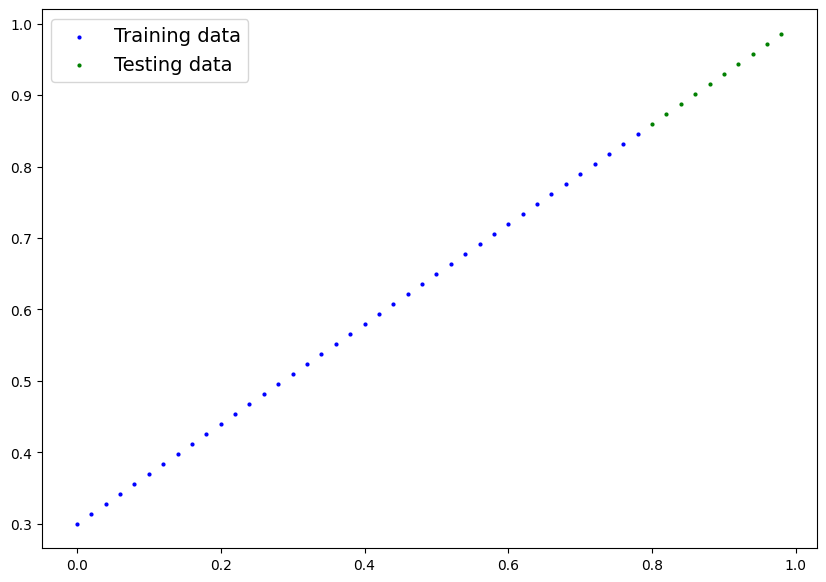

In [24]:
plot_predictions(X_train, y_train, X_test, y_test)

# 6.2 PyTorch 선형 모델 만들기

- nn.Parameter() 사용해서 가중치와 편향을 직접 정의하는 대신 nn.Linear(in_features, out_features) 사옹해 PyTorch가 자동으로 처리하도록 할 것 <br>
in_features : 입력 데이터를 가지는 차원 수 <br>
out_features : 출력하고 싶은 데이터 차원 수 <br>

각 레이블(y)에 대해 입력 특성(X)이 1개뿐이기 때문에,
이 두 값 모두 1


In [25]:
# nn.Module을 상속해서 모델 클래스 정의
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Linear()를 사용해 모델의 파라미터(가중치, 편향) 생성
        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1
        )
        
    # 순전파(forward) 계산 정의
    # 입력 데이터 x가 nn.Linear()를 통과
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)     # 수식으로 쓰면 y=weight*x+bias
    
# 모델 생성 시 수동으로 시드(seed) 고정
# (항상 필요한 것 아니고 예제 위해 사용)

# 모델 인스턴스 생성
model_1 = LinearRegressionModelV2()

# 모델 구조와 모델의 state_dict(학습 파라미터) 출력
model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[-0.2191]])),
              ('linear_layer.bias', tensor([0.2018]))]))

model_1.state_dict()의 출력 결과 -> nn.Linear() 레이어가 무작위로 초기화된 가중치와 편향 파라미터를 자동으로 생성해준 것을 확인 가능

- 모델을 GPU로 옮기기 <br>
Pytorch 객체의 디바이스는 .to(device) 메서드 사용해서 변경 가능

In [26]:
# 모델의 현재 디바이스 확인
next(model_1.parameters()).device

device(type='cpu')

In [27]:
# GPU가 사용 가능하면 GPU로, 아니면 CPU로 모델 이동
model_1.to(device)  # device 변수는 위에서 'cuda' 또는 'cpu'로 이동
next(model_1.parameters()).device

device(type='cuda', index=0)

우리가 디바이스에 구애받지 않는(device agnostic) 코드를 작성했기 때문에 GPU 있든 없든 위 코드 정상 작동

In [28]:
for k, v in model_1.state_dict().items():
    print(k, v.shape, v.device)

linear_layer.weight torch.Size([1, 1]) cuda:0
linear_layer.bias torch.Size([1]) cuda:0


# 6.3 학습

- 학습 & 테스트 루프 만들기
-손실 함수 (loss function)와 optimizer가 필요 <br>
-nn.L1Loss()와 torch.optim.SGD()를 사용 <br> 
-옵티마이저가 학습 중에 모델의 파라미터를 조정할 수 있도록, 새로 만든 모델의 파라미터(model.parameters)를 옵티마이저에 전달해야함 <br>
-이전에 잘 동작했던 학습률(learning rate) 0.01도 다시 사용 <br>

In [29]:
# 손실 함수 생성
loss_fn = nn.L1Loss()

#옵티마이저 생성
optimizer = torch.optim.SGD(
    params=model_1.parameters(),    # 새로 만든 모델의 파라미터를 최적화 대상으로 지정
    lr=0.01
)

-이전 학습 루프와 비교했을 때 이번 단계에서 유일하게 달라지는 점 -> 데이터를 목표 디바이스로 옮긴다는 것 <br>
-우리는 model_1.to(device)를 사용해 모델을 목표 디바이스로 옮김

- 데이터도 같은 방식으로 옮기기 <br>
모델이 GPU에 있으면 → 데이터도 GPU <br>
모델이 CPU에 있으면 → 데이터도 CPU <br>
 => 디바이스 불일치 에러 피하기



In [30]:
print(next(model_1.parameters()).device)
print(X_train.device)

cuda:0
cpu


In [31]:
torch.manual_seed(42)  # 난수 시드 고정

epochs = 1000

# 데이터들을 사용 가능한 디바이스로 이동 
# 이 과정 생략하면 모데로가 데이터가 다른 디바이스에 있게 돼어 에러 발생
X_train = X_train.to(device)
X_test  = X_test.to(device)
y_train = y_train.to(device)
y_test  = y_test.to(device)

# epoch 수만큼 학습 반복
for epoch in range(epochs) :
    
    ### Training (훈련 단계)
    
    
    #모델을 학습 모드로 설정- 모델 생성 직후 기본값이지만 명시하는게 좋음
    model_1.train()
    
    # 1. 순전파 (forward pass)
    # 훈련 데이터로 예측값 생성
    y_pred = model_1(X_train)
    
    # 2. 손실(Loss) 계산
    # 예측값(y_pred)과 실제값(y_train)의 차이를 수치로 계산
    loss = loss_fn(y_pred, y_train)
    
    # 3. 이전 step에서 계산된 gradient 초기화 (안하면 gradient 누적됨)
    optimizer.zero_grad()
    
    # 4. 역전파 (Backward pass)
    #loss를 기준으로 각 파라미터에 대한 기울기 계산
    loss.backward()
    
    # 5. optimizer step
    # 계산된 gradient를 이요해 가중치(weight, gradient) 업데이트
    optimizer.step()
    
    ### Testing (평가 단계)
    
    # 모델을 평가 모드로 설정
    # (Dropout, BatchNorm이 평가용 동작)
    model_0.eval()
    
    #inference_mode():
    #gradient 계산 x -> 메모리 절약 & 속도 증가
    with torch.inference_mode():
        
        # 1. 테스트 데이터로 예측
        test_pred = model_1(X_test)
        
        # 2. 테스트 손실 계산
        # 예측값은 float이므로 y_test도 float으로 맞춰줌
        test_loss = loss_fn(test_pred, y_test)

        # 100 epcoh마다 결과 출력
        if epoch % 100 == 0:
            print(
                f"Epoch: {epoch} | "
                f"Train Loss: {loss} | "
                f"Test Loss: {test_loss}"
            )
    
    


Epoch: 0 | Train Loss: 0.4566597044467926 | Test Loss: 0.902740478515625
Epoch: 100 | Train Loss: 0.1262269765138626 | Test Loss: 0.3064868450164795
Epoch: 200 | Train Loss: 0.09164690971374512 | Test Loss: 0.2134605497121811
Epoch: 300 | Train Loss: 0.057300865650177 | Test Loss: 0.1334826797246933
Epoch: 400 | Train Loss: 0.02296038530766964 | Test Loss: 0.05281791836023331
Epoch: 500 | Train Loss: 0.0034435198176652193 | Test Loss: 0.007161492016166449
Epoch: 600 | Train Loss: 0.0034435198176652193 | Test Loss: 0.007161492016166449
Epoch: 700 | Train Loss: 0.0034435198176652193 | Test Loss: 0.007161492016166449
Epoch: 800 | Train Loss: 0.0034435198176652193 | Test Loss: 0.007161492016166449
Epoch: 900 | Train Loss: 0.0034435198176652193 | Test Loss: 0.007161492016166449


*epoch : 훈련 데이터를 한 번 전부 본 것


이제 모델이 학습한 파라미터들을 확인하고 처음에 직접 하드코딩했던 원래 파라미터 값들과 비교해보기

*하드코딩 : 값이나 설정을 코드 안에 '직접 박아 넣는 것'

In [32]:
# 모델이 학습한 파라미터(가중치, 평향) 확인

from pprint import pprint
#pptint = pretty print
#딕셔너리 같은 구조를 보기 좋게 출력해주는 도구

print("모델이 학습한 가중치와 편향 값은 다음과 같음:")
pprint(model_1.state_dict())

print("\n 그리고 처음에 우리가 하드코딩했던 가중치와 편향 값은 다음과 같음:")
print(f"weights: {weight}, bias: {bias}")

모델이 학습한 가중치와 편향 값은 다음과 같음:
OrderedDict([('linear_layer.weight', tensor([[0.6943]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2988], device='cuda:0'))])

 그리고 처음에 우리가 하드코딩했던 가중치와 편향 값은 다음과 같음:
weights: 0.7, bias: 0.3


*pprint : 딕셔너리나 리스트를 보기 좋게 출력해주는 함수 <br>
**state_dict() : 모델이 학습하면서 얻은 모든 "상태값(파라미터)"을 담아둔 딕셔너리 <br>


- 실제 상황에서는 완벽한 파라미터를 미리 알고 있는 경우는 거의 없음

# 6.4 예측하기 (Making Predictions)

- 학습된 모델을 가지고 있으니, 모델을 평가 모드로 전환한 뒤 예측해보기



In [33]:
# 모델을 평가 모드로 전환
model_1.eval()

# 테스트 데이터들로 예측하기 
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8542],
        [0.8681],
        [0.8820],
        [0.8959],
        [0.9097],
        [0.9236],
        [0.9375],
        [0.9514],
        [0.9653],
        [0.9792]], device='cuda:0')

GPU에 있는 데이터로 예측하고 있어서 결과 끝에 device='cuda:0' 표시있음 <br>
-> 해당 데이터가 cuda device 0 에 있다는 뜻 (제로 인덱싱을 사용하기 때문에, 시스템이 접근할 수 있는 첫 번째 GPU 의미) <br>

-pandas, matplotlib, NumPy 같은 데이터 사이언스 라이브러리들은 GPU에 저장된 데이터를 직접 사용할 수 없음 <br>
-> 대상 텐서에 .cpu()를 호출해서 CPU로 복사한 뒤 사용

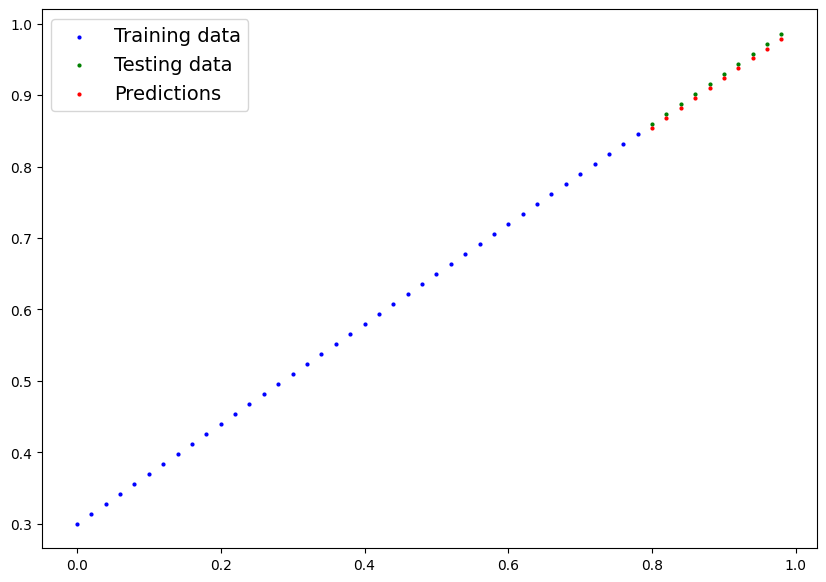

In [34]:
# plot_predictions(predictions=y_preds) # -> 데이터가 CPU에 없어서 작동 x

#데이터 CPU에 넣고 plot 하기
plot_predictions(predictions=y_preds.cpu())

# 6.5 모델 저장하고 불러오기

- 학습이 끝난 model_1의 가중치와 편향 값만(state_deict) models/01_pytorch_workflow_model_1.pth 파일로 저장하는 코드

In [36]:
from pathlib import Path

# 1. 모델을 저장할 디렉토리 생성
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. 모델을 저장할 파일 경로 생성
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. 모델 state_dict 지정
print(f"모델을 다음 경로에 저장합니다: {MODEL_SAVE_PATH}")
torch.save(
    obj=model_1.state_dict(),   # 모델의 학습된 파라미터(state_dict)만 저장
    f=MODEL_SAVE_PATH
)

모델을 다음 경로에 저장합니다: models\01_pytorch_workflow_model_1.pth


- 제대로 동작했는지 확인하기 위해 저장한 모델 다시 불러오기

1. LinearRegressionModelV2() 클래스의 새 인스턴스 생성
2. torch.nn.Module.load_state_dict() 사용해 저장된 모델의 state_dict를 불러옴
3. 코드가 디바이스에 독립적(device-agnostic)으로 동작하도록 새로 만든 모델 인스턴스를 목표 디바이스로 옮기기

In [41]:
# LinearRegressionModelV2 클래스의 새 인스턴스 생성

loaded_model_1 = LinearRegressionModelV2()  #빈 모델(랜덤 가중치 상태) 생성

# 저장해 두었던 모델의 state_dict 불러오기
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH)) # 파일에 저장돼 있던 state_dict 불러와서 방금 만든 새 모델에 학습된 가중치&편향 덮어씌움 -> loaded_model_1이 학습 끝난 모델과 동일한 상태가 됨
 
 # .to(device) 이요해 모델을 목표 디바이스로 이동
 # (데이터가 GPU에 있다면, 예측을 하려면 모델도 GPU에 있어야 함)
loaded_model_1.to(device)
 
 # 불러온 모델 구조 출력
print(f"불러온 모델:\n{loaded_model_1}")
 
 # 모델 파라미터가 올라가 있는 디바이스 출력
print(f"모델이 올라가 있는 디바이스:\n{next(loaded_model_1.parameters()).device}")

불러온 모델:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
모델이 올라가 있는 디바이스:
cuda:0


In [42]:
# 불러온 모델 평가하기
loaded_model_1.eval()       # 모델을 평가 모드로 전환
with torch.inference_mode():    #gradient 계산 끄기
    loaded_model_1_preds = loaded_model_1(X_test)   #테스트 데이터를 모델에 넣어 예측값 생성
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')